# Spotify Song Popularity Analysis
### DSA-609 Mini Data Science Project
**Method:** Random Forest Regressor &nbsp;|&nbsp; **Dataset:** Spotify Tracks Dataset (Kaggle — Maharshi Pandya, 2023) &nbsp;|&nbsp; **[Your Name] | March 2026**

## Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Load the Data

In [ ]:
# Load the dataset
df = pd.read_csv('dataset.csv')
df.head()

   Unnamed: 0              track_id              artists       album_name      track_name  popularity  duration_ms  explicit  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence   tempo  time_signature track_genre
0           0  5SuOikwiRyPMVoIQDJUgSV         Gen Hoshino            Comedy          Comedy          73       230666     False         0.676   0.461    1    -6.746     0       0.1430        0.0322          0.000001     0.3580    0.715  87.917               4    acoustic
1           1  4qPNDBW1i3p13qLCt0Ki3A        Ben Woodward  Ghost (Acoustic)  Ghost - Acoustic  55       149610     False         0.420   0.166    1   -17.235     1       0.0763        0.9240          0.000006     0.1010    0.267  77.489               4    acoustic
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson  To Begin Again    To Begin Again    57       210826     False         0.438   0.359    0    -9.734     1       0.0557        0.2100       

In [ ]:
df.shape

(114000, 21)

## Clean and Preprocess Data

In [ ]:
# 1. Remove unnecessary columns (index, identifiers)
df = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name'])

# 2. Standardise genre labels
df['track_genre'] = df['track_genre'].str.strip()

# 3. Convert explicit column from boolean to integer
df['explicit'] = df['explicit'].astype(int)

# 4. Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0

In [ ]:
# 5. Fill any remaining missing values with 0
df.fillna(0, inplace=True)

print('Missing values after fill:')
print(df.isnull().sum())

Missing values after fill:
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0

In [ ]:
# 6. Check for and remove duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Duplicate rows after removal: {df.duplicated().sum()}')

Duplicate rows: 7093
Duplicate rows after removal: 0

In [ ]:
df.shape

(106907, 16)

## Exploratory Data Analysis

In [ ]:
# 1. Basic statistics
feat_cols = ['popularity', 'danceability', 'energy', 'loudness',
             'acousticness', 'valence', 'tempo']
print('\nBasic Statistics:')
print(df[feat_cols].describe())


Basic Statistics:
       popularity  danceability     energy   loudness  speechiness  acousticness  instrumentalness
count   106907.00     106907.00  106907.00  106907.00    106907.00     106907.00         106907.00
mean        35.36          0.57       0.64      -8.30         0.09          0.31              0.16
std         21.34          0.17       0.25       5.06         0.11          0.33              0.31
min          0.00          0.00       0.00     -49.53         0.00          0.00              0.00
25%         20.00          0.45       0.47     -10.08         0.04          0.02              0.00
50%         37.00          0.58       0.69      -7.06         0.05          0.17              0.00
75%         51.00          0.69       0.86      -5.02         0.08          0.60              0.07
max        100.00          0.98       1.00       4.53         0.96          1.00              1.00

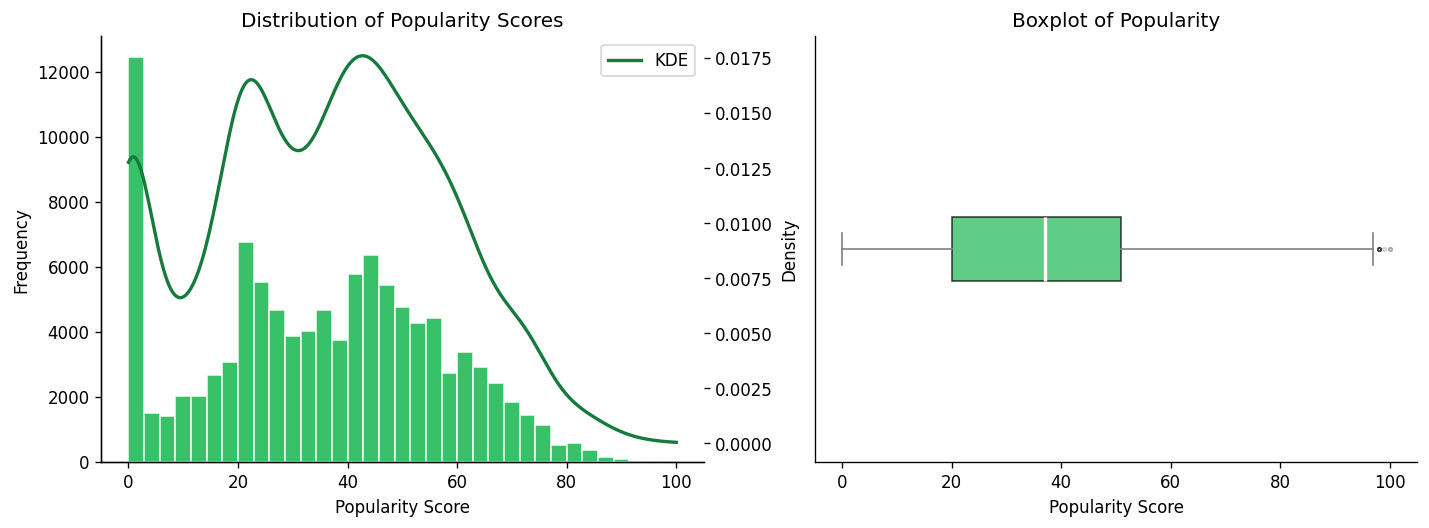

In [ ]:
# 2. Popularity Distribution Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram with KDE overlay
ax1.hist(df['popularity'], bins=35, color='#1DB954', edgecolor='white', alpha=0.88)
from scipy.stats import gaussian_kde
kx = np.linspace(0, 100, 300)
kde = gaussian_kde(df['popularity'].sample(5000, random_state=42))
ax1b = ax1.twinx()
ax1b.plot(kx, kde(kx), color='#157A3B', lw=2, label='KDE')
ax1b.set_ylabel('Density')
ax1b.legend(loc='upper right')
ax1.set_title('Distribution of Popularity Scores')
ax1.set_xlabel('Popularity Score')
ax1.set_ylabel('Frequency')

# Boxplot
ax2.boxplot(df['popularity'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#1DB954', alpha=0.7),
            medianprops=dict(color='white', lw=2))
ax2.set_title('Boxplot of Popularity')
ax2.set_xlabel('Popularity Score')
plt.tight_layout()
plt.show()

### 3. Popularity by Genre

track_genre
pop-film     59.272362
k-pop        58.366530
chill        54.801839
pop          54.360412
sad          52.801411
grunge       50.133603
indian       49.576730
emo          49.410678
anime        48.762525
sertanejo    47.861862
dtype: float64

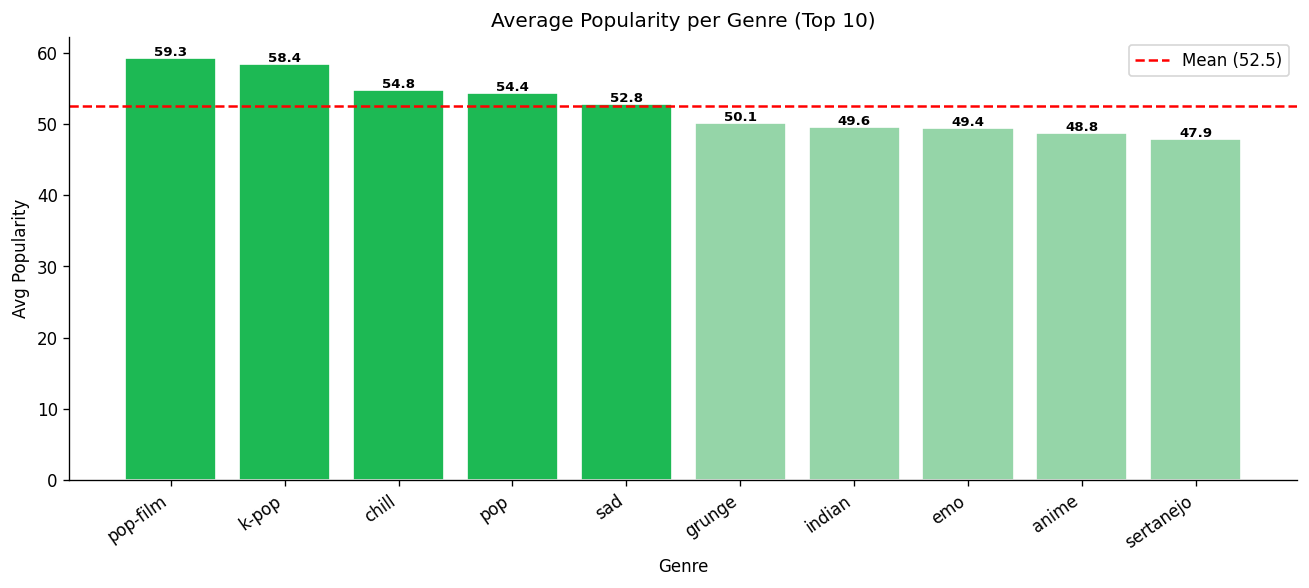

In [ ]:
# Average popularity per genre (top 10 most popular genres)
avg_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
print(avg_pop)

avg_pop.plot(kind='bar', figsize=(11, 5), color='#1DB954', edgecolor='white')
plt.title('Average Popularity per Genre (Top 10)')
plt.ylabel('Average Popularity')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 4. Principal Component Analysis (PCA)

In [ ]:
# Select audio features for PCA
feat = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo',
        'duration_ms', 'explicit', 'key', 'mode', 'time_signature']

# Standardise the data
scaler = StandardScaler()
scaled = scaler.fit_transform(df[feat])

# Perform PCA
pca = PCA()
pca.fit(scaled)

eigenvalues = pca.explained_variance_
print('Eigenvalues (Explained Variance):')
print(eigenvalues[:6])

total_variation = sum(eigenvalues)
print(f'\nTotal Variation: {total_variation:.4f}')

Eigenvalues (Explained Variance):
[2.97803978  1.54818872  1.38499203  1.19771688  1.03498569  0.95586843 ...]

Total Variation: 14.0001

In [ ]:
# Proportion of variance per component
proportions = eigenvalues / total_variation
cumulative_prop = np.cumsum(proportions)

print('Proportion of Total Variation for Each Principal Component:')
for i, (prop, cum) in enumerate(zip(proportions, cumulative_prop)):
    print(f'PC{i+1}: {prop:.4f} ({prop*100:.2f}%)  Cumulative: {cum*100:.2f}%')


Proportion of Total Variation for Each Principal Component:
PC1: 0.2127 (21.27%)  Cumulative: 21.27%
PC2: 0.1106 (11.06%)  Cumulative: 32.33%
PC3: 0.0989 (9.89%)  Cumulative: 42.22%
PC4: 0.0856 (8.56%)  Cumulative: 50.78%
PC5: 0.0739 (7.39%)  Cumulative: 58.17%
PC6: 0.0683 (6.83%)  Cumulative: 65.00%
PC7: 0.0636 (6.36%)  Cumulative: 71.36%
PC8: 0.0609 (6.09%)  Cumulative: 77.45%
PC9: 0.0599 (5.99%)  Cumulative: 83.44%
PC10: 0.0557 (5.57%)  Cumulative: 89.01%
PC11: 0.0441 (4.41%)  Cumulative: 93.42%
PC12: 0.0325 (3.25%)  Cumulative: 96.68%
PC13: 0.0233 (2.33%)  Cumulative: 99.00%
PC14: 0.0100 (1.00%)  Cumulative: 100.00%


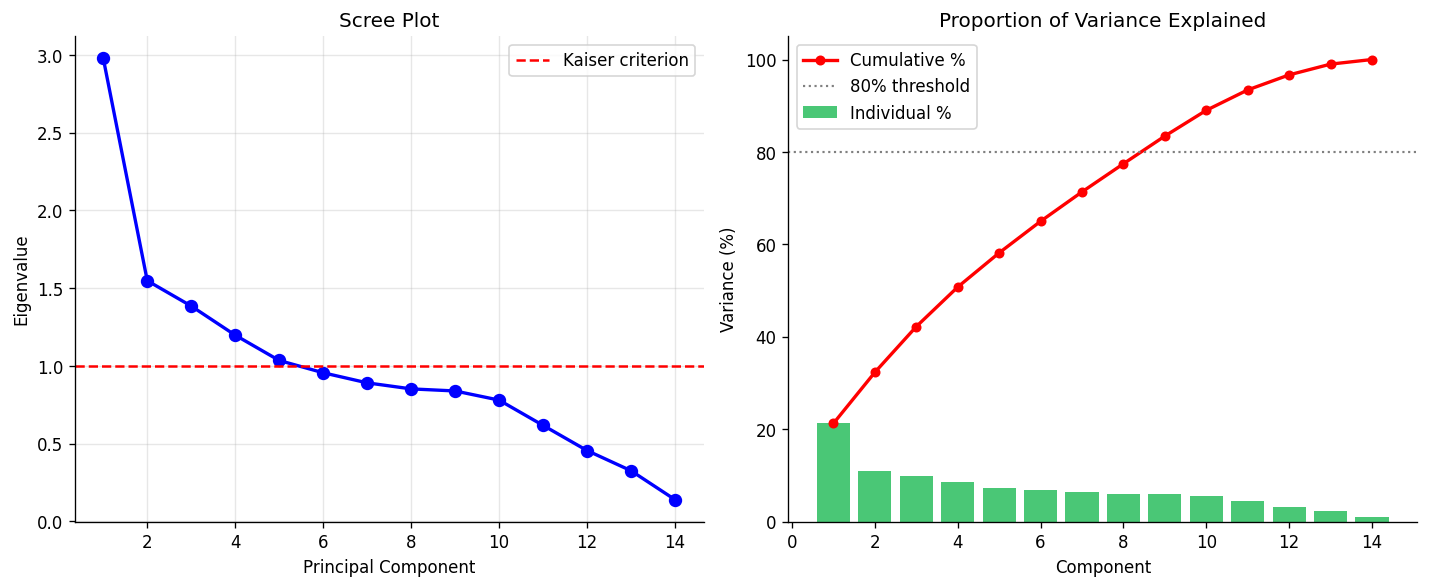

In [ ]:
# Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
ax1.axhline(y=1, color='r', linestyle='--', label='Kaiser criterion')
ax1.set_title('Scree Plot')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue (Explained Variance)')
ax1.legend()
ax1.grid()

ax2.bar(range(1, len(proportions)+1), proportions*100,
        color='#1DB954', alpha=0.8, label='Individual %')
ax2.plot(range(1, len(cumulative_prop)+1), cumulative_prop*100,
         'r-o', lw=2, ms=5, label='Cumulative %')
ax2.axhline(80, color='gray', linestyle=':', lw=1.3, label='80% threshold')
ax2.set_title('Proportion of Variance Explained')
ax2.set_xlabel('Component')
ax2.set_ylabel('Variance (%)')
ax2.legend()
plt.tight_layout()
plt.show()

### 5. Genre-wise Insights

track_genre
mandopop       1000
samba          1000
cantopop        999
j-idol          999
mpb             999
sertanejo       999
tango           999
anime           998
death-metal     998
forro           998
Name: track_genre, dtype: int64

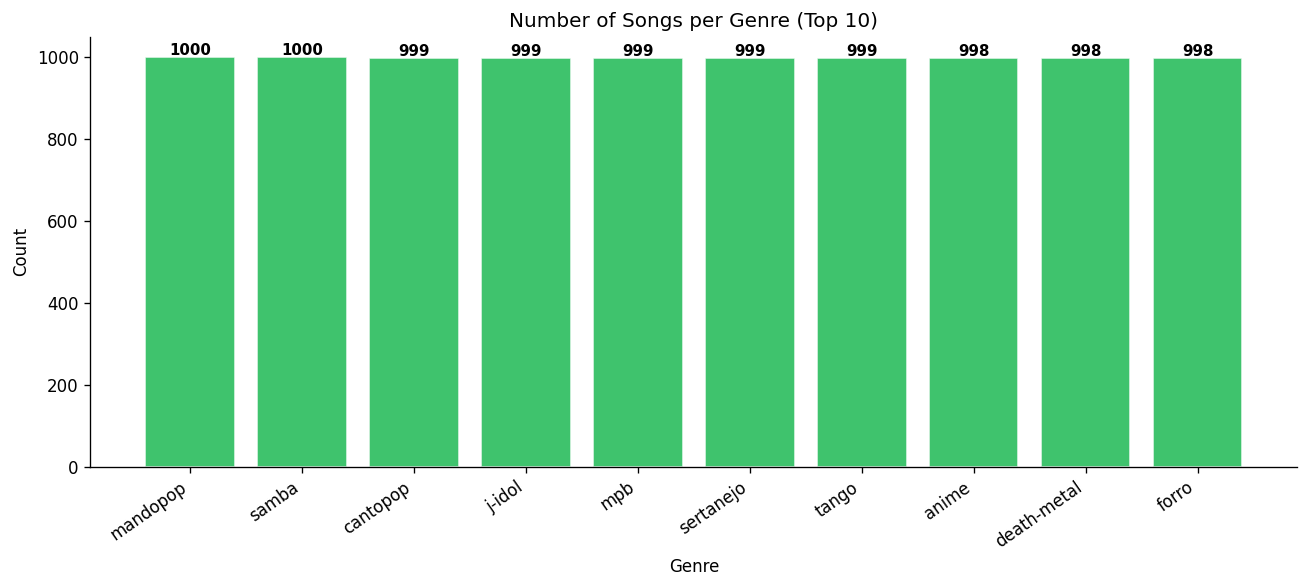

In [ ]:
# Number of songs per genre (top 10)
cnt = df['track_genre'].value_counts().head(10)
print(cnt)

plt.figure(figsize=(11, 5))
bars = plt.bar(cnt.index, cnt.values, color='#1DB954', edgecolor='white', alpha=0.85)
for bar, v in zip(bars, cnt.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(v), ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Number of Songs per Genre (Top 10)')
plt.tight_layout()
plt.show()

             danceability    energy  acousticness
track_genre                                      
anime            0.537428  0.673704      0.268230
cantopop         0.547902  0.461810      0.536023
death-metal      0.368189  0.931591      0.006708
forro            0.649947  0.789501      0.397362
j-idol           0.548758  0.868593      0.151523
mandopop         0.546532  0.498434      0.480288
mpb              0.574111  0.579858      0.420606
samba            0.574897  0.672644      0.489903
sertanejo        0.591560  0.710403      0.436632
tango            0.537882  0.372482      0.846241

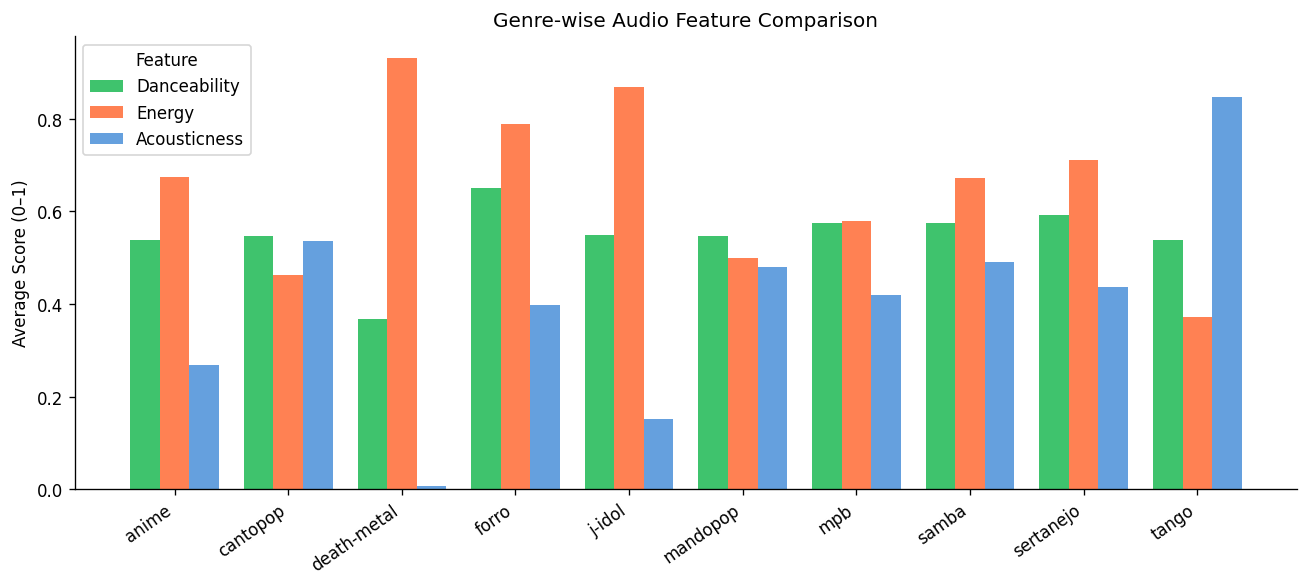

In [ ]:
# Genre-wise audio feature comparison (top 10 genres)
top_genres = df['track_genre'].value_counts().head(10).index
df_top = df[df['track_genre'].isin(top_genres)]
genre_stats = df_top.groupby('track_genre')[['danceability', 'energy', 'acousticness']].mean()
print(genre_stats)

x = np.arange(len(genre_stats))
w = 0.26
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, genre_stats['danceability'], w, label='Danceability', color='#1DB954', alpha=0.85)
ax.bar(x,     genre_stats['energy'],       w, label='Energy',       color='#FF6B35', alpha=0.85)
ax.bar(x + w, genre_stats['acousticness'], w, label='Acousticness', color='#4A90D9', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(genre_stats.index, rotation=35, ha='right')
ax.set_title('Genre-wise Audio Feature Comparison')
ax.set_ylabel('Average Score (0–1)')
ax.legend(title='Feature')
plt.tight_layout()
plt.show()

### 6. Correlation Analysis

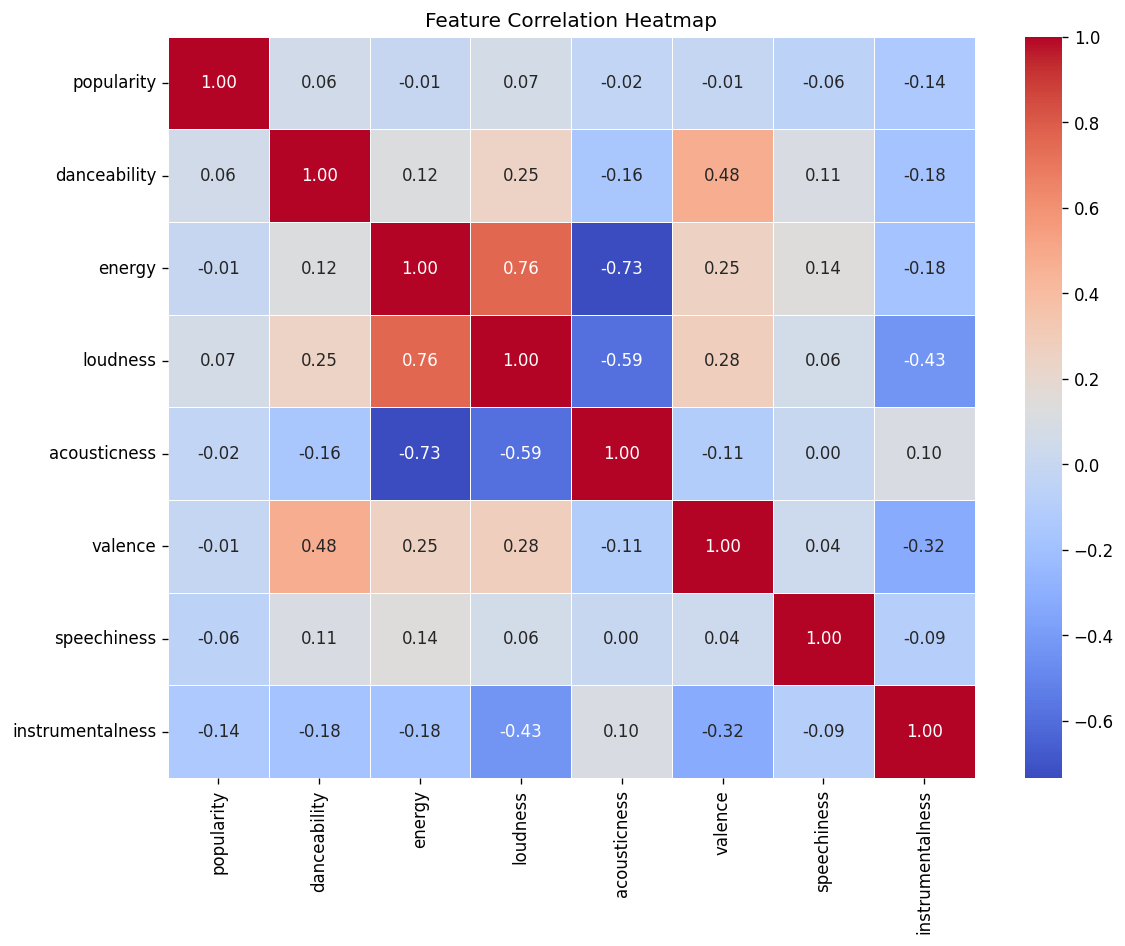

In [ ]:
# Correlation heatmap
corr_cols = ['popularity', 'danceability', 'energy', 'loudness',
             'acousticness', 'valence', 'speechiness', 'instrumentalness']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

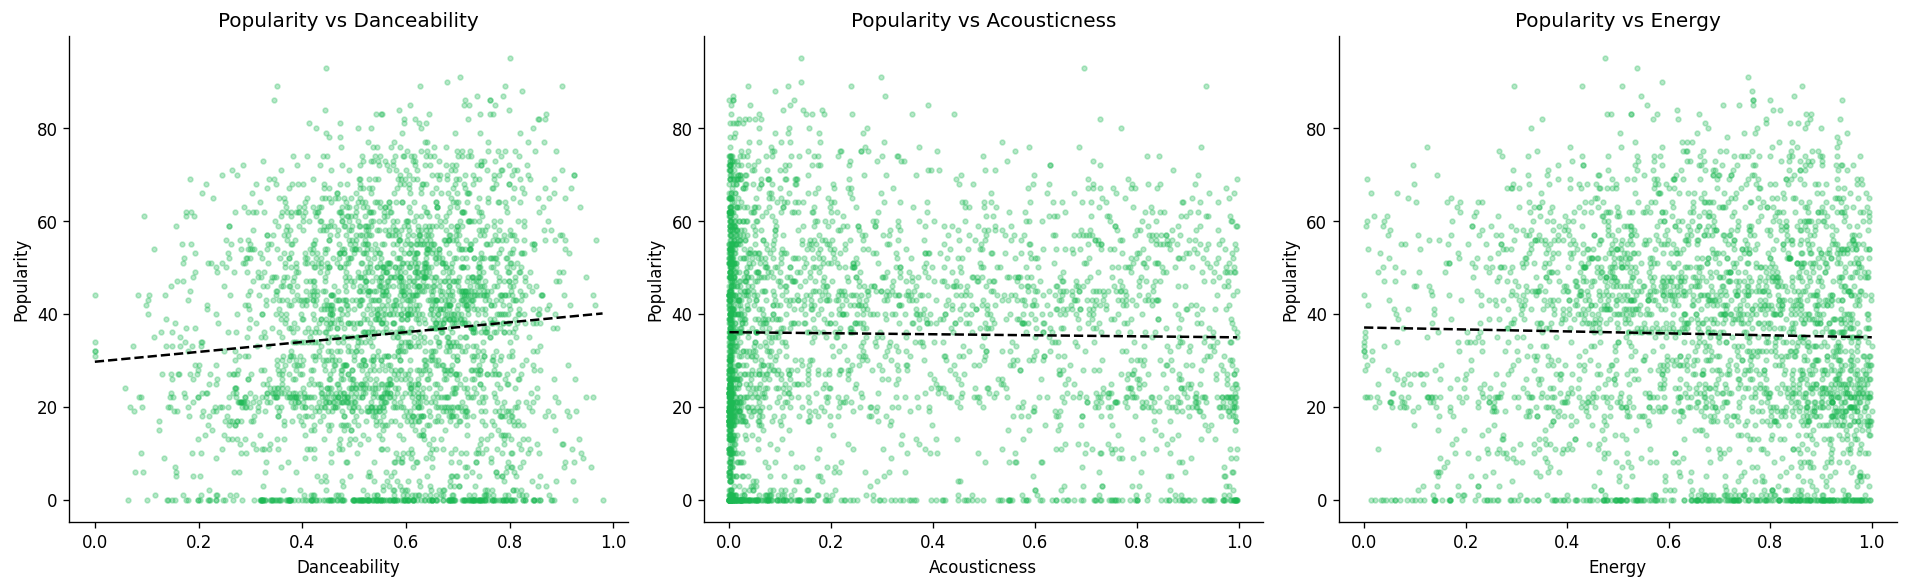

In [ ]:
# Scatter plots — audio features vs popularity (sample of 3,000 songs)
sample = df.sample(3000, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('danceability', 'Danceability'),
         ('acousticness', 'Acousticness'),
         ('energy', 'Energy')]

for ax, (col, lbl) in zip(axes, pairs):
    ax.scatter(sample[col], sample['popularity'], alpha=0.3, s=8, color='#1DB954')
    m, b = np.polyfit(sample[col], sample['popularity'], 1)
    xl = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(xl, m*xl + b, 'k--', lw=1.5)
    ax.set_xlabel(lbl)
    ax.set_ylabel('Popularity')
    ax.set_title(f'Popularity vs {lbl}')

plt.tight_layout()
plt.show()

## ML / AI Method — Random Forest Regressor

In [ ]:
# Select features and target variable
feat = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo',
        'duration_ms', 'explicit', 'key', 'mode', 'time_signature']

X = df[feat]
y = df['popularity']

# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

In [ ]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('\nRandom Forest Performance:')
print('MAE:', mean_absolute_error(y_test, rf_pred))
print('MSE:', mean_squared_error(y_test, rf_pred))
print('R2 Score:', r2_score(y_test, rf_pred))


Random Forest Performance:
MAE: 11.842531906823282
MSE: 258.6611343125448
R2 Score: 0.4333392772737462

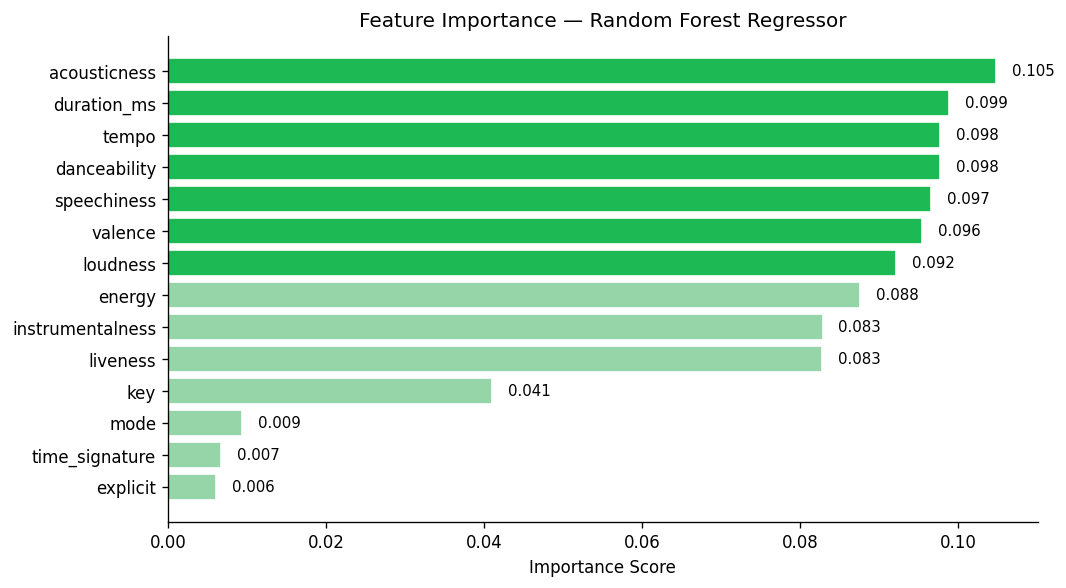

In [ ]:
# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1DB954' if v >= feat_imp.median() else '#95d5a8' for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
for bar, v in zip(ax.patches, feat_imp.values):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
ax.set_title('Feature Importance — Random Forest Regressor')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

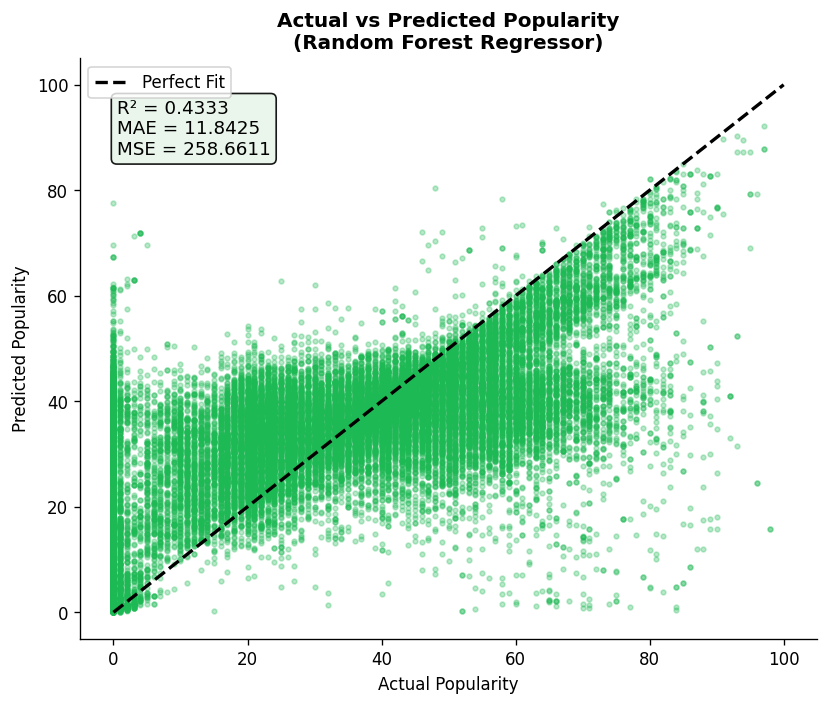

In [ ]:
# Actual vs Predicted Popularity
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, s=8, color='#1DB954')
plt.plot([0, 100], [0, 100], 'k--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity\n(Random Forest Regressor)')
plt.text(0.05, 0.92, 'R\u00b2 = 0.4333\nMAE = 11.8425\nMSE = 258.6611',
         transform=plt.gca().transAxes, fontsize=11, va='top',
         bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))
plt.legend()
plt.tight_layout()
plt.show()